In [1]:
#Write Code Here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import re
import string
import warnings
warnings.filterwarnings('ignore')
import time

import nltk
nltk.download('stopwords',     quiet=True)

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)
from sklearn.decomposition import PCA

print("All imports successful ✓")

All imports successful ✓


In [2]:
class MentalHealthClassifier:
    def __init__(self, filepath):
        """
        Initializes the classifier with attributes defined in the design specs.
        """
        # Data Storage
        self.filepath = filepath
        self.dataset = None
        self.cleaned_dataset = None
        self.labels = None
        
        # Train/Test Split Storage
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        
        self.vectorizer = None
        self.X_train_tfidf = None
        self.X_test_tfidf = None
        self.knn_model = None
        self.predictions = None
        
        self.evaluation_metrics = {}
        self.confusion_matrices = {}
        
        self.timing_data = {}

    def load_data(self):
        
        #Loads the dataset from the CSV file.
        self.dataset = pd.read_csv(self.filepath)
        print(f"Data successfully loaded")

    def clean_data(self):
        
        # Creates a working copy
        df = self.dataset.copy()

        # Handles empty or null entries and print the count
        initial_count = len(df)
        df = df.dropna(subset=['post_text', 'label'])
        print(f"Removed {initial_count - len(df)} rows with missing attributes.")

        # Load English stopwords
        stop_words = set(stopwords.words('english'))

    
        def process_text(text):
            # (i) Convert to lowercase
            text = str(text).lower() 
            
            # (ii) Remove URLs, mentions (@user), and special characters
            text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) 
            text = re.sub(r'@\w+', '', text) 
            text = re.sub(r'[^\w\s]', '', text) 
            
            # (iii) Remove stopwords
            words = text.split()
            filtered_words = [word for word in words if word not in stop_words]
            return " ".join(filtered_words)

        
        # Apply the cleaning function
        df['post_text'] = df['post_text'].apply(process_text)

        # Update the class attributes
        self.cleaned_dataset = df
        self.labels = df['label'] # 0 = non-depressive, 1 = depressive
        
        print("Data cleaning complete.")
        
    
    def split_data(self, split_ratio: float = 0.8):
        
        #Spliting the cleaned dataset into training and testing sets.
        
        
        # Features (X) are the cleaned text, Target (y) is the label
        X = self.cleaned_dataset['post_text']
        y = self.labels

        # Use scikit-learn to split the data randomly
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, train_size=split_ratio, random_state=42
        )
    def extract_features(self, ngram_range=(1, 1)):
        
        
        #ngram_range: (1,1) for unigrams, (1,2) for bigrams, (1,3) for trigrams.
        
        # Initialise the vectorizer
        self.vectorizer = TfidfVectorizer(ngram_range=ngram_range)
        
        # Fit and transform the data
        self.X_train_tfidf = self.vectorizer.fit_transform(self.X_train)
        self.X_test_tfidf = self.vectorizer.transform(self.X_test)
        
        print(f"Feature extraction complete using ngram_range: {ngram_range}")

    def train_model(self):
        #Trains the k-NN classifier on the training data
        
        
        self.knn_model = KNeighborsClassifier(n_neighbors=5)
        
        # Teach the model 
        self.knn_model.fit(self.X_train_tfidf, self.y_train)
        print("k-NN Model successfully trained.")

    def test_model(self):
        
        self.predictions = self.knn_model.predict(self.X_test_tfidf)
        print("Predictions generated for testing data.")
        return self.predictions

    def visualise_results(self, predictions):
        
        labels = ["Non-depressive", "Depressive"]
        # generates a confusion matrix
        cm = confusion_matrix(self.y_test, predictions)
        
        # Plot using Seaborn heatmap
        plt.figure(figsize=(6, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",      
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels
        )
        
        plt.title("Confusion Matrix: k-NN Predictions")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.tight_layout()
        plt.show()
        
    def apply_pca(self, target_variance=0.80, explore_limit=100):
        
        #Apply standard PCA by first converting TF-IDF sparse matrices to dense arrays
        
   
        #  Convert sparse TF-IDF matrices to dense arrays
        X_train_dense = self.X_train_tfidf.toarray()
        X_test_dense = self.X_test_tfidf.toarray()

        
        #  Apply exploratory PCA
        pca_explore = PCA(n_components=explore_limit, random_state=42)
        pca_explore.fit(X_train_dense)

        # Cumulative explained variance plot
        cumulative_variance_pca = np.cumsum(pca_explore.explained_variance_ratio_)

        plt.figure(figsize=(8, 4))
        plt.plot(range(1, explore_limit + 1), cumulative_variance_pca, marker="o", markersize=4, 
                 color="seagreen", linewidth=2, label="Cumulative Explained Variance")
        plt.axhline(y=target_variance, color="tomato", linestyle="--", linewidth=1.5, label=f"{int(target_variance*100)}% Threshold")
        
        plt.title("Cumulative Explained Variance by Number of PCA Components")
        plt.xlabel("Number of Components")
        plt.ylabel("Cumulative Explained Variance")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

        # 4. Identify the number of components needed to reach the target variance
        
        n_components_pca = int(np.argmax(cumulative_variance_pca >= target_variance)) + 1
        print(f"Components needed to explain {int(target_variance*100)}% of variance: {n_components_pca}")

        # 5. Reduce features and store them 
        print("Running final PCA reduction")
        self.pca = PCA(n_components=n_components_pca, random_state=42)
        
        self.X_train_reduced = self.pca.fit_transform(X_train_dense)
        self.X_test_reduced = self.pca.transform(X_test_dense)
        
        print("Dimensionality reduction complete.")  
    def train_reduced_model(self):
        
        #Trains the k-NN classifier using the reduced feature matrices
        self.knn_model_reduced = KNeighborsClassifier(n_neighbors=5)
        
        
        self.knn_model_reduced.fit(self.X_train_reduced, self.y_train)
        print("Reduced k-NN Model successfully trained.")

    def test_reduced_model(self):
       
        # We generate predictions using the reduced model and reduced testing data
        predictions = self.knn_model_reduced.predict(self.X_test_reduced)
        return predictions
    
    def compare_scenarios(self):
        
        scenarios = [
            {"split": 0.8, "use_pca": False, "name": "80-20 split without PCA"},
            {"split": 0.7, "use_pca": False, "name": "70-30 split without PCA"},
            {"split": 0.8, "use_pca": True,  "name": "80-20 split with PCA"},
            {"split": 0.7, "use_pca": True,  "name": "70-30 split with PCA"}
        ]
        
        for s in scenarios:
            print(f"\nRunning: {s['name']}")
            self.split_data(split_ratio=s["split"])
            self.extract_features()
            
            if s["use_pca"]:
                self.apply_pca(target_variance=0.80) 
                
                start_train = time.time()
                self.train_reduced_model()
                end_train = time.time()
                
                start_test = time.time()
                predictions = self.test_reduced_model()
                end_test = time.time()
            else:
                start_train = time.time()
                self.train_model()
                end_train = time.time()
                
                start_test = time.time()
                predictions = self.test_model()
                end_test = time.time()
                
            # Calculate the time durations
            train_time = end_train - start_train
            test_time = end_test - start_test
            total_time = train_time + test_time
            
            # 1. Store the Timing Data (Task 3)
            self.timing_data[s["name"]] = {
                "Training Time (s)": round(train_time, 4),
                "Testing Time (s)": round(test_time, 4),
                "Total Time (s)": round(total_time, 4)
            }
            
            # 2. Store the Accuracy Metrics (Task 2)
            self.store_metrics(predictions, s["name"])
            
    def store_metrics(self, predictions, scenario_name):
        
        # Save the metrics into a dictionary
        self.evaluation_metrics[scenario_name] = {
            "Accuracy": accuracy_score(self.y_test, predictions),
            "Precision": precision_score(self.y_test, predictions, zero_division=0),
            "Recall": recall_score(self.y_test, predictions, zero_division=0),
            "F1-Score": f1_score(self.y_test, predictions, zero_division=0)
        }
        
        # Save the raw confusion matrix math for the grid plot
        self.confusion_matrices[scenario_name] = confusion_matrix(self.y_test, predictions)

    def plot_matrix_grid(self):
   
        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        axes = axes.flatten() # Flattens the 2x2 grid into a simple list of 4
        
        for idx, (scenario, cm) in enumerate(self.confusion_matrices.items()):
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-depress", "Depress"])
            disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
            axes[idx].set_title(scenario)
            
        plt.tight_layout()
        plt.show()

    def plot_accuracy_chart(self):
        # Generates a bar chart comparing accuracies
        
        
        # Extract the names and accuracy numbers from our dictionary
        scenarios = list(self.evaluation_metrics.keys())
        accuracies = [metrics["Accuracy"] for metrics in self.evaluation_metrics.values()]
        
        plt.figure(figsize=(8, 5))
        plt.bar(scenarios, accuracies, color='steelblue')
        plt.title("Accuracy Comparison Across Scenarios")
        plt.ylabel("Accuracy")
        plt.ylim(0, 1.0) # Accuracies are percentages, so lock Y-axis at 1.0 (100%)
        plt.xticks(rotation=15)
        plt.show()
    def plot_timing_results(self):
        # Creates a grouped bar chart comparing training and testing times.
        
        
        scenarios = list(self.timing_data.keys())
        train_times = [data["Training Time (s)"] for data in self.timing_data.values()]
        test_times = [data["Testing Time (s)"] for data in self.timing_data.values()]
        
        
        x = np.arange(len(scenarios))
        width = 0.35  
        
        fig, ax = plt.subplots(figsize=(10, 6))
        # Draw Training bars shifted slightly to the left, Testing to the right
        ax.bar(x - width/2, train_times, width, label='Training Time', color='skyblue')
        ax.bar(x + width/2, test_times, width, label='Testing Time', color='salmon')
        
        ax.set_ylabel('Time (seconds)')
        ax.set_title('Execution Time by Scenario (Training vs Testing)')
        ax.set_xticks(x)
        ax.set_xticklabels(scenarios, rotation=15)
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.show()

    def analyze_tradeoff(self):
        # Displays a table and a scatter plot to compare Accuracy vs Processing Time.
        
        
        # 1. Build a merged table of Accuracy and Total Time
        tradeoff_data = []
        for scenario in self.timing_data.keys():
            tradeoff_data.append({
                "Scenario": scenario,
                "Accuracy": round(self.evaluation_metrics[scenario]["Accuracy"], 4),
                "Total Time (s)": round(self.timing_data[scenario]["Total Time (s)"], 4)
            })
            
        df = pd.DataFrame(tradeoff_data)
        print("\n" + "="*60)
        print("TRADE-OFF ANALYSIS: ACCURACY VS COMPUTATIONAL EFFICIENCY")
        print("="*60)
        print(df.to_string(index=False))
        
        # 2. Create a Scatter Plot to visually show the trade-off
        plt.figure(figsize=(9, 6))
        
        colors = ['steelblue', 'lightblue', 'darkgreen', 'lightgreen']
        for i, row in df.iterrows():
            plt.scatter(row["Total Time (s)"], row["Accuracy"], 
                        color=colors[i], s=150, label=row["Scenario"])
            
        plt.title("Dimensionality Reduction: Accuracy vs. Efficiency Trade-off")
        plt.xlabel("Total Processing Time (Seconds) --> Faster is Better")
        plt.ylabel("Accuracy Score --> Higher is Better")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend()
        
        plt.tight_layout()
        plt.show()

Data successfully loaded
Removed 0 rows with missing attributes.
Data cleaning complete.
Feature extraction complete using ngram_range: (1, 1)
k-NN Model successfully trained.
Predictions generated for testing data.
Predictions generated for testing data.


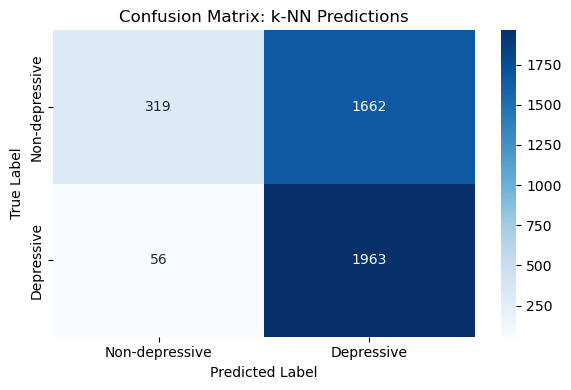

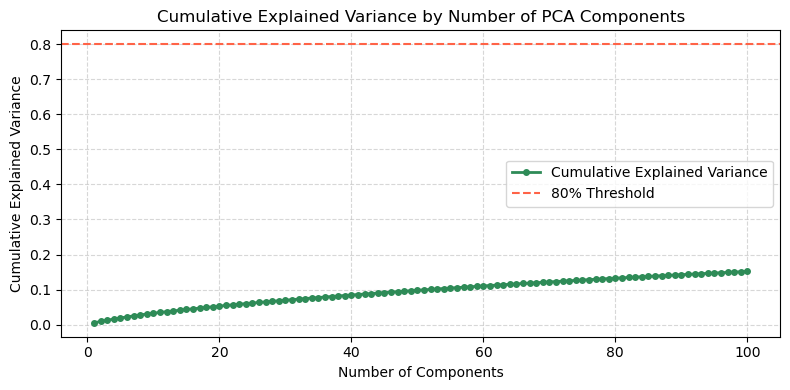

Components needed to explain 80% of variance: 1
Running final PCA reduction
Dimensionality reduction complete.


In [3]:
twitter = MentalHealthClassifier("Mental-Health-Twitter1.csv")
twitter.load_data()
twitter.clean_data()
twitter.split_data()
twitter.extract_features()
twitter.train_model()
twitter.test_model()
twitter.visualise_results(twitter.test_model())
twitter.apply_pca()


Running: 80-20 split without PCA
Feature extraction complete using ngram_range: (1, 1)
k-NN Model successfully trained.
Predictions generated for testing data.

Running: 70-30 split without PCA
Feature extraction complete using ngram_range: (1, 1)
k-NN Model successfully trained.
Predictions generated for testing data.

Running: 80-20 split with PCA
Feature extraction complete using ngram_range: (1, 1)


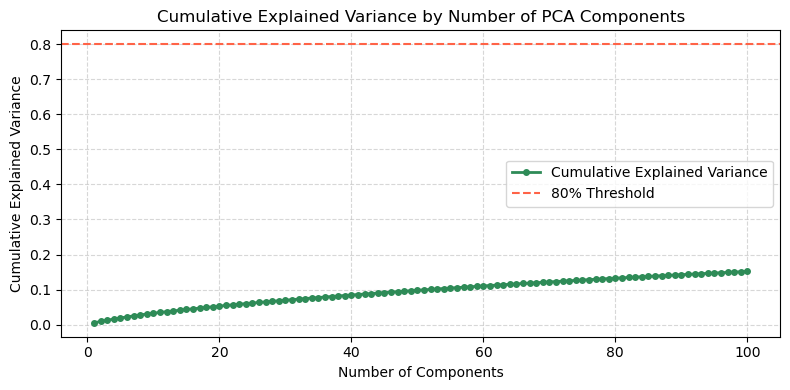

Components needed to explain 80% of variance: 1
Running final PCA reduction
Dimensionality reduction complete.
Reduced k-NN Model successfully trained.

Running: 70-30 split with PCA
Feature extraction complete using ngram_range: (1, 1)


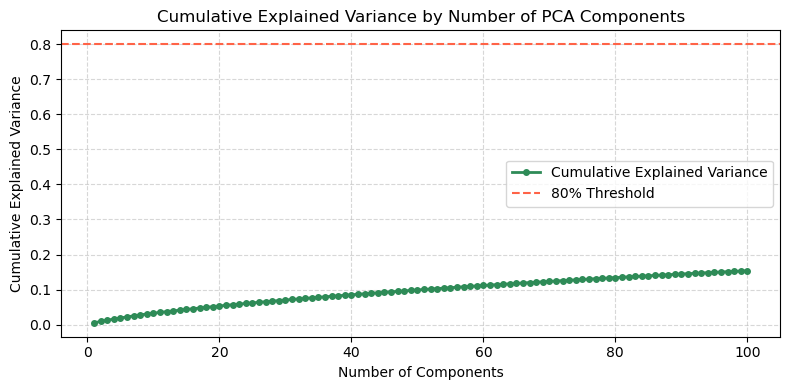

Components needed to explain 80% of variance: 1
Running final PCA reduction
Dimensionality reduction complete.
Reduced k-NN Model successfully trained.


In [4]:
twitter.compare_scenarios()

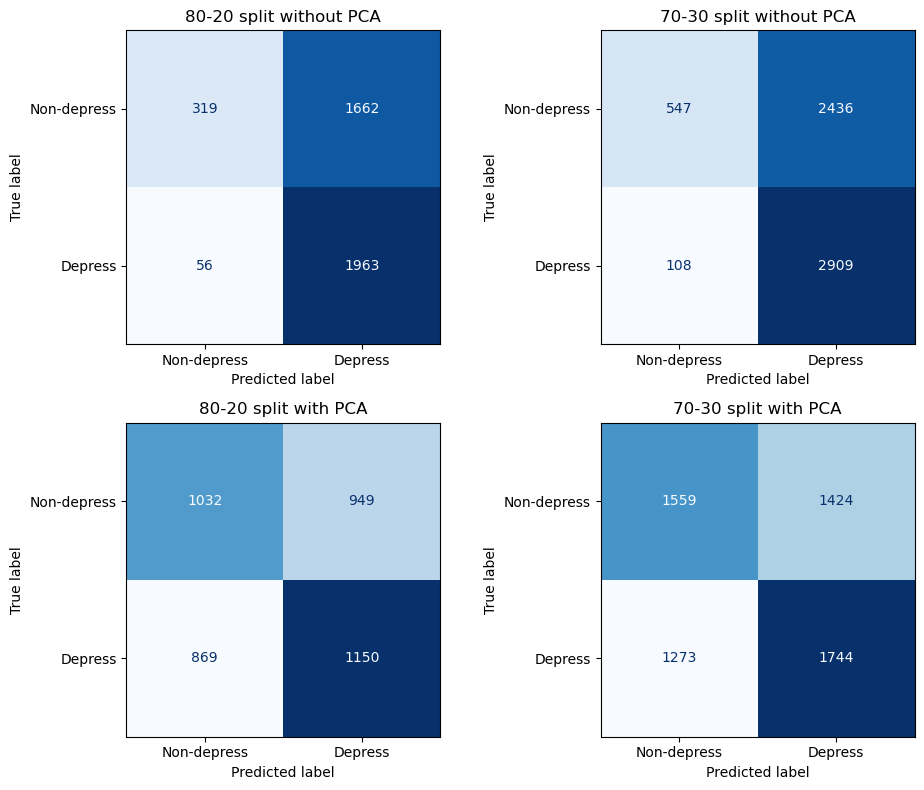

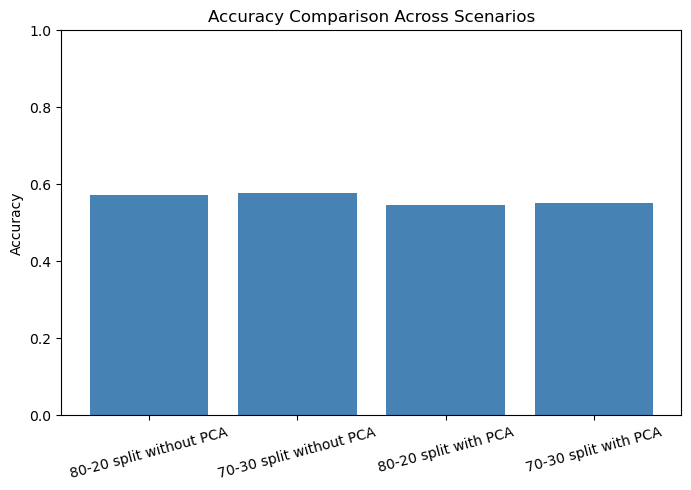

In [5]:
twitter.plot_matrix_grid()
twitter.plot_accuracy_chart()

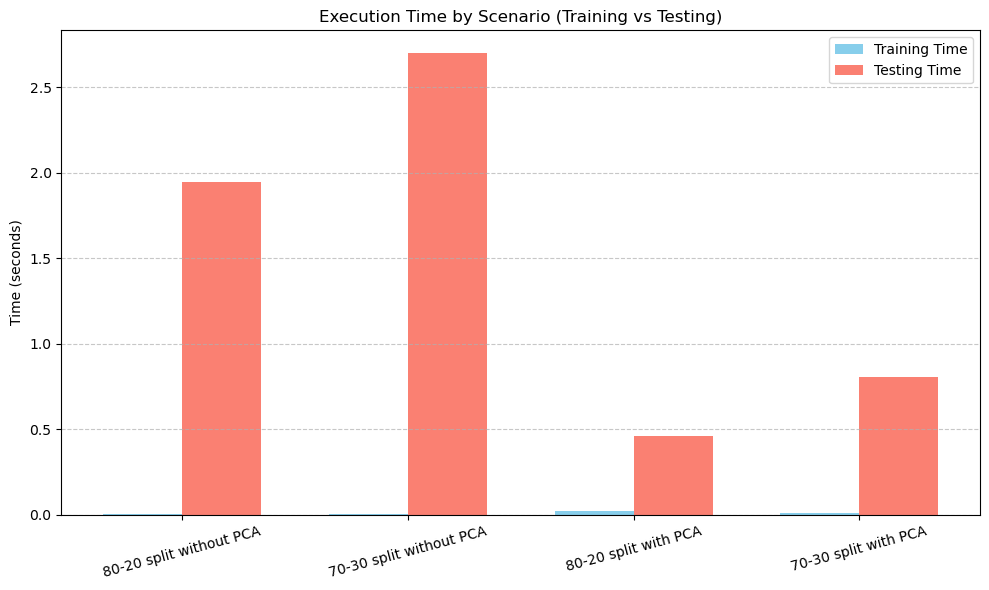


TRADE-OFF ANALYSIS: ACCURACY VS COMPUTATIONAL EFFICIENCY
               Scenario  Accuracy  Total Time (s)
80-20 split without PCA    0.5705          1.9471
70-30 split without PCA    0.5760          2.7013
   80-20 split with PCA    0.5455          0.4777
   70-30 split with PCA    0.5505          0.8181


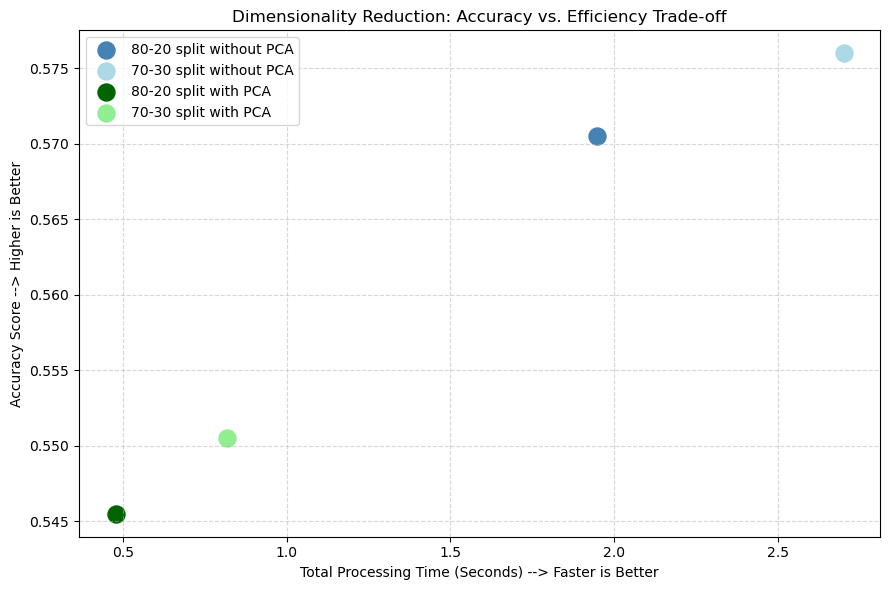

In [6]:
twitter.plot_timing_results()
twitter.analyze_tradeoff()

# Reflection

### Object-Oriented Design Decisions and Benefits
I designed the MentalHealthClassifier class to act as a self-contained pipeline. My rationale for the attribute choices was to use the __init__ method as a central "storage room" (e.g., self.X_train, self.pca, self.evaluation_metrics) so that the state of the data could be preserved across different stages of the machine learning process.

The primary benefit of using Object-Oriented Programming (OOP) for this task was extensibility..For dimensionality reduction, I didn't have to rewrite the entrire code. I simply added an apply_pca() method and integrated it into the existing flow. Furthermore, OOP made the code highly reusable; the compare_scenarios method was able to loop through four different setups by simply calling the same functions with different parameters, making the code much cleaner and easier to maintain.

### Insights on Classification and Dimensionality Reduction
One of the most significant insights was learning about "accuracy paradox". Initially, running the k-NN classifier on the raw TF-IDF data yielded a slightly higher overall accuracy. However, the confusion matrix revealed that the model was over-predicting the majority class, resulting in massive false positives. It was struggling with the "curse of dimensionality" across thousands of sparse word columns.

When I applied PCA, the overall accuracy dropped slightly, but the model became more balanced and realistic.By reducing the noise down to its principal components, the k-NN algorithm was able to calculate distances much more effectively, drastically reducing false alarms and drastically speeding up the computational testing time.

### Strengths, Limitations, and Implementation Challenges
A major strength of this implementation is its automation; the single compare_scenarios method handles data routing, timing, and metric storage seamlessly. However, a significant limitation of this class design is its strict method dependency. Because the class relies on instance attributes updated in real-time, the methods must be executed in a highly specific order (e.g., extract_features will immediately crash if split_data hasn't been run first to populate self.X_train).

Additionally, a technical challenge arose when integrating standard PCA with TF-IDF. Because TF-IDF generates sparse matrices and standard sklearn PCA requires dense arrays, I had to use .toarray() to uncompress the data. This created a high memory overhead, highlighting a limitation in how this specific pipeline scales with massive text datasets.

### Responsible Real-World Application
When implementted in the real world as an early detection system for mental health support, this classifier must be used strictly as a supplementary tool and never as a diagnostic one. Natural Language Processing can't efficiently process sarcasm, context, or slang which can lead to misclassifications.

The system ought to be used in a sense that it serves as a triage mechanism. For example, if this mechanism is used by a social media platform to detect wheather it's users are in depression, the output should not trigger an automated medical response.Rather, it should redirect the profile of that user to a human moderator or display some useful mental health resources (such as hotline numbers or automated check-ins) to that user. Balancing the reduction of false negatives (missing someone in crisis) with false positives (spamming safe users) is critical to maintaining user trust and privacy.